# Artificial Immune Pattern Recognition for Structure Damage Classification
**Author:** @VedantAndhale

## Data Dictionary and Specification
The synthetic dataset of 200 samples will have the following features:
- **feature_1**: Vibration frequency (Hz)
- **feature_2**: Displacement amplitude (mm)
- **feature_3**: Strain (microstrain)
- **feature_4**: Temperature (°C)
- **damage_class**: Class label (0 = No Damage, 1 = Minor Damage, 2 = Major Damage)

| Feature        | Type    | Description                        | Example Value |
|---------------|---------|------------------------------------|--------------|
| feature_1     | float   | Vibration frequency in Hz          | 12.5         |
| feature_2     | float   | Displacement amplitude in mm       | 0.8          |
| feature_3     | float   | Strain in microstrain              | 250          |
| feature_4     | float   | Temperature in Celsius             | 35           |
| damage_class  | integer | Damage class (0, 1, or 2)          | 1            |

## Step 1: Generate Synthetic Data
We create a dataset that simulates sensor readings from a structure. The damage class is determined by thresholds on the features.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 200

# Generate features
feature_1 = np.random.normal(loc=15, scale=5, size=n_samples)  # Vibration frequency
feature_2 = np.random.normal(loc=1, scale=0.3, size=n_samples)  # Displacement amplitude
feature_3 = np.random.normal(loc=300, scale=100, size=n_samples)  # Strain
feature_4 = np.random.normal(loc=30, scale=5, size=n_samples)  # Temperature

# Generate damage classes based on feature thresholds
conditions = [
    (feature_1 > 18) & (feature_2 < 1) & (feature_3 < 350),
    (feature_1 < 12) | (feature_2 > 1.2) | (feature_3 > 400),
]
damage_class = np.select(conditions, [0, 2], default=1)

data = pd.DataFrame(
    {
        "Vibration_frequency": feature_1,
        "Displacement_amplitude": feature_2,
        "Strain": feature_3,
        "Temperature": feature_4,
        "damage_class": damage_class,
    }
)
data.head()

,Vibration_frequency,Displacement_amplitude,Strain,Temperature,damage_class
0,17.483571,1.107336,140.557234,33.784943,1
1,14.308678,1.168235,240.062498,25.389173,1
2,18.238443,1.324915,300.524370,34.348030,2
3,22.615149,1.316141,304.698059,36.778189,2
4,13.829233,0.586699,254.993453,32.067175,1


## Step 2: Visualize the Data
Let's visualize the distribution of features and the class balance to understand the dataset.

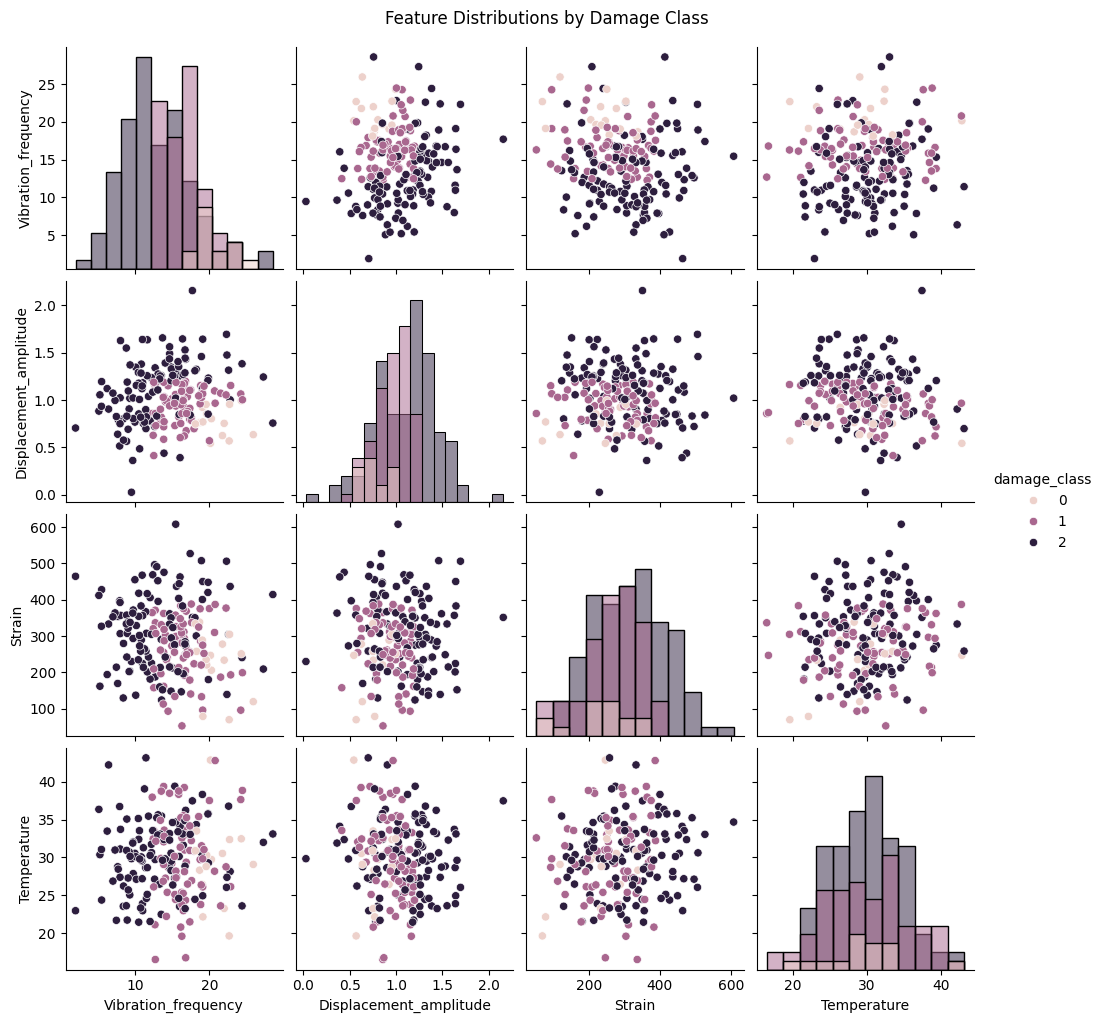

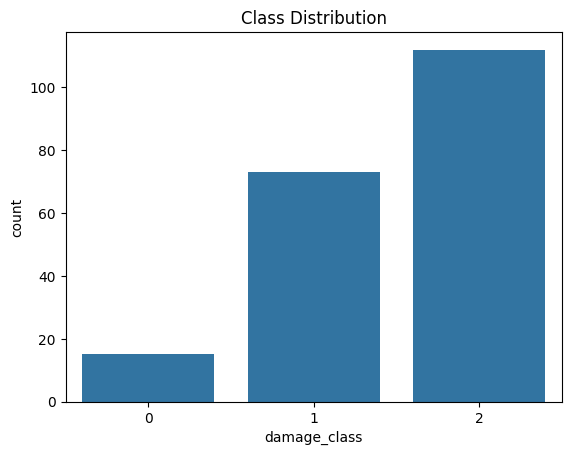

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(data, hue="damage_class", diag_kind="hist")
plt.suptitle("Feature Distributions by Damage Class", y=1.02)
plt.show()

sns.countplot(x="damage_class", data=data)
plt.title("Class Distribution")
plt.show()

## Step 3: Artificial Immune System (AIS) Classifier
We will implement a simple AIS-based classifier. The algorithm works by generating random detectors (analogous to immune cells) and assigning them to classes based on their affinity to training samples.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Split the data
X = data.drop("damage_class", axis=1).values
y = data["damage_class"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


def generate_detectors(X, y, n_detectors=30):
    idx = np.random.choice(len(X), n_detectors, replace=False)
    return X[idx], y[idx]


def affinity(a, b):
    # Euclidean distance (lower = higher affinity)
    return np.linalg.norm(a - b)


def classify_ais(X_train, y_train, X_test, n_detectors=30):
    detectors, detector_labels = generate_detectors(X_train, y_train, n_detectors)
    y_pred = []
    for sample in X_test:
        distances = np.array([affinity(sample, d) for d in detectors])
        best_idx = np.argmin(distances)
        y_pred.append(detector_labels[best_idx])
    return np.array(y_pred)


def grid_search_ais(X_train, y_train, X_test, y_test):
    best_accuracy = 0
    best_n_detectors = 0
    for n_detectors in range(10, 101, 10):
        y_pred = classify_ais(X_train, y_train, X_test, n_detectors)
        accuracy = np.mean(y_pred == y_test)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_n_detectors = n_detectors
    return best_n_detectors, best_accuracy


# Optimize the number of detectors
best_n_detectors, best_accuracy = grid_search_ais(X_train, y_train, X_test, y_test)
print(
    f"Best number of detectors: {best_n_detectors}, Best accuracy: {best_accuracy:.2f}"
)

# Re-train with the best number of detectors
y_pred = classify_ais(X_train, y_train, X_test, best_n_detectors)
print(classification_report(y_test, y_pred))

Best number of detectors: 90, Best accuracy: 0.83
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.75      0.67      0.71        18
           2       0.89      0.92      0.90        36

    accuracy                           0.83        60
   macro avg       0.79      0.81      0.79        60
weighted avg       0.83      0.83      0.83        60



## Step 4: Evaluate the Results
We evaluate the classifier using a confusion matrix and a classification report to understand its performance.

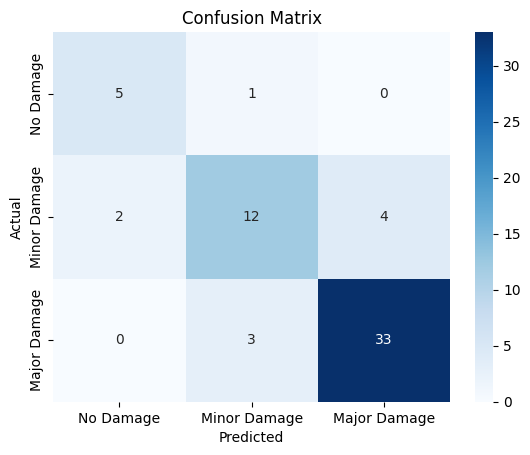

In [4]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Damage", "Minor Damage", "Major Damage"],
    yticklabels=["No Damage", "Minor Damage", "Major Damage"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()